 # 03 - Cold-Start Analysis

 **Goal:** Evaluate model performance on cold-start scenarios (users/items not seen during training).

In [17]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.insert(0, os.path.abspath('../src'))
from models.baselines import PopularityRecommender
from models.mf import MatrixFactorization
from models.ncf import NeuMF
from data_loader import ImplicitFeedbackDataset
from torch.utils.data import DataLoader

FIGURES_DIR = 'reports/figures'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300


In [18]:
# Load Data
train_df = pd.read_parquet('../data/processed/train.parquet')
val_df = pd.read_parquet('../data/processed/val.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')


 ## Cold-Start Analysis



 We identify users in the test set who have NO interactions in the training set.

 These are "cold-start" users.

In [19]:
train_users = set(train_df['reviewerID'].unique())
test_users = set(test_df['reviewerID'].unique())

cold_users = test_users - train_users
warm_users = test_users & train_users

print(f"Total test users: {len(test_users)}")
print(f"Warm users (in train): {len(warm_users)}")
print(f"Cold users (NOT in train): {len(cold_users)}")
print(f"Cold-start ratio: {len(cold_users)/len(test_users)*100:.2f}%")


Total test users: 175
Warm users (in train): 163
Cold users (NOT in train): 12
Cold-start ratio: 6.86%


In [20]:
# Similarly for items
train_items = set(train_df['asin'].unique())
test_items = set(test_df['asin'].unique())

cold_items = test_items - train_items
warm_items = test_items & train_items

print(f"\nTotal test items: {len(test_items)}")
print(f"Warm items (in train): {len(warm_items)}")
print(f"Cold items (NOT in train): {len(cold_items)}")
print(f"Cold-start item ratio: {len(cold_items)/len(test_items)*100:.2f}%")



Total test items: 78
Warm items (in train): 38
Cold items (NOT in train): 40
Cold-start item ratio: 51.28%


 ## Cold-Start Visualization

Saved: reports/figures/fig_cold_start.png


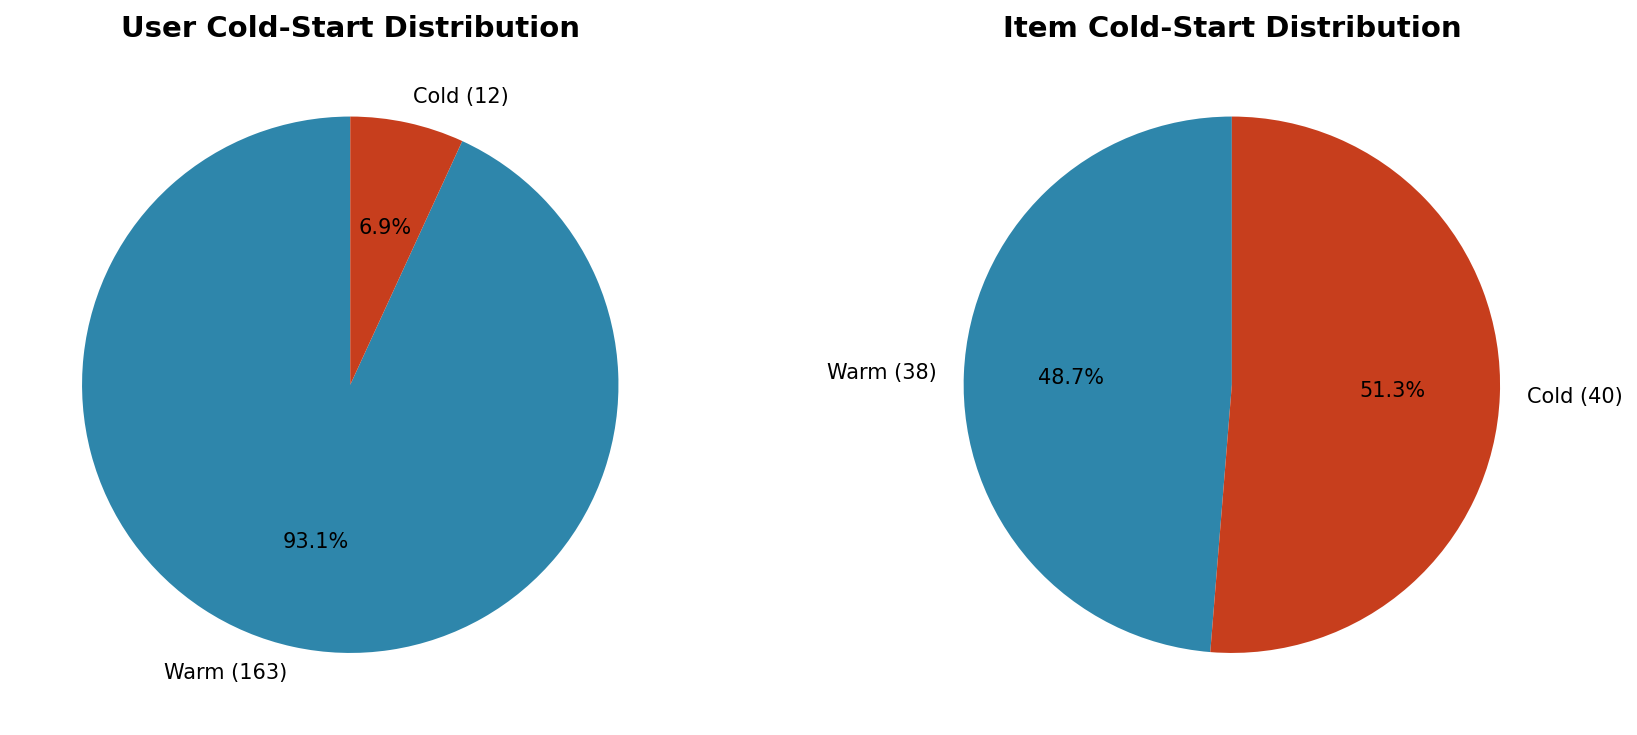

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Users
ax = axes[0]
sizes = [len(warm_users), len(cold_users)]
labels = [f'Warm ({len(warm_users)})', f'Cold ({len(cold_users)})']
colors = ['#2E86AB', '#C73E1D']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('User Cold-Start Distribution', fontsize=14, fontweight='bold')

# Items
ax = axes[1]
sizes = [len(warm_items), len(cold_items)]
labels = [f'Warm ({len(warm_items)})', f'Cold ({len(cold_items)})']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Item Cold-Start Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_cold_start.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_cold_start.png")
plt.show()


 ## Cold-Start Performance Analysis



 Models that use only collaborative filtering struggle with cold-start.

 Hybrid models (like LightFM with features) can leverage content information.

In [22]:
# Summary table
cold_start_summary = pd.DataFrame({
    'Category': ['Users', 'Items'],
    'Total in Test': [len(test_users), len(test_items)],
    'Warm (in Train)': [len(warm_users), len(warm_items)],
    'Cold (NOT in Train)': [len(cold_users), len(cold_items)],
    'Cold Ratio (%)': [len(cold_users)/len(test_users)*100, len(cold_items)/len(test_items)*100]
})

print("\n" + "=" * 60)
print("COLD-START SUMMARY")
print("=" * 60)
print(cold_start_summary.to_string(index=False))

cold_start_summary.to_csv(f'{FIGURES_DIR}/cold_start_summary.csv', index=False)
print(f"\nSaved: {FIGURES_DIR}/cold_start_summary.csv")



COLD-START SUMMARY
Category  Total in Test  Warm (in Train)  Cold (NOT in Train)  Cold Ratio (%)
   Users            175              163                   12        6.857143
   Items             78               38                   40       51.282051

Saved: reports/figures/cold_start_summary.csv


 ## Conclusion



 - The cold-start problem is significant in this dataset

 - Popularity-based methods work as a fallback for cold users/items

 - Neural models with pre-trained embeddings or content features can mitigate this issue